# IoT Traffic Analysis v9 — Packet-only (No Direction) (Time windows + MAC)

v9 time windows + strict direction. Direction now uses the dataset MAC embedded in the filename when available (still strict; fails if missing).

In [10]:
# If running in a fresh environment, install deps as needed:
# !pip install scapy tensorflow scikit-learn pandas numpy matplotlib

import os
import math
import random
import re
import numpy as np
import pandas as pd

from scapy.all import PcapReader
from scapy.layers.l2 import Ether, Dot3
from scapy.layers.inet import IP, TCP, UDP

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 1) Dataset location

In [11]:
# === UPDATE THIS PATH ===
PCAP_DIR = "unsw-dataset/pcaps"   # e.g. "/content/pcaps" or "./pcaps"

assert os.path.isdir(PCAP_DIR), f"PCAP_DIR not found: {PCAP_DIR}"
pcap_files = sorted([os.path.join(PCAP_DIR, f) for f in os.listdir(PCAP_DIR) if f.endswith(".pcap")])

print("PCAP count:", len(pcap_files))
print("Example:", pcap_files[:3])


PCAP count: 27
Example: ['unsw-dataset/pcaps/AmazonEcho_44650d56ccd3.pcap', 'unsw-dataset/pcaps/AugustDoorBell_e076d03f00ae.pcap', 'unsw-dataset/pcaps/AwairAirQuality_70886b100fc6.pcap']


## 2) Mapping

In [12]:
from collections import Counter

device_to_type_v7 = {
    "SamsungCamera_00166cab6b88": "camera_streamer",
    "BelkinCamera_b4750eece5a9": "camera_streamer",
    "NestDropCam_308cfb2fe4b2": "camera_streamer",
    "TPLinkCamera_f4f26D9351f1": "camera_streamer",
    "CanaryCamera_7c70bc5d5edc": "camera_streamer",
    "NetatmoWelcome_70ee50183443": "camera_streamer",
    "WithingsBabyMonitor_0024e41118a8": "camera_streamer",
    "RingDoorBell_884aea31669d": "camera_streamer",
    "AugustDoorBell_e076d03f00ae": "camera_streamer",

    "AwairAirQuality_70886b100fc6": "sensor_meter",
    "NetatmoWeatherStation_70ee5003b8ac": "sensor_meter",
    "WithingsSleepSensor_0024e42028c6": "sensor_meter",
    "WithingsSmartScale_0024e41b6f96": "sensor_meter",
    "BlipCareBPMeter_746a89002e25": "sensor_meter",
    "NestProtect_18b43025bee4": "sensor_meter",
    "BelkinWemoMotionSensor_ec1a59832811": "sensor_meter",

    "PhilipsHue_0017882b9a25": "actuator_light_plug",
    "LiFXBulb_d073d5018308": "actuator_light_plug",
    "TPLinkSmartPlug_50c7bf005639": "actuator_light_plug",
    "BelkinWemoSwitch_ec1a5979f489": "actuator_light_plug",

    "SamsungSmartThings_d052a800675e": "hub_gateway_bridge",
    "HPPrinter_705a0fe49bc0": "hub_gateway_bridge",

    "TribySpeaker_18B79E022044": "media_speaker_display",
    "PixStarPhotoFrame_e076d033bb85": "media_speaker_display",
    "HelloBarbie_28c2ddffa52d": "media_speaker_display",
    "iHome_74c63b29d71d": "media_speaker_display",
    "AmazonEcho_44650d56ccd3": "media_speaker_display",
}

v7_to_v8 = {
    "camera_streamer": "continuous_streaming",
    "sensor_meter": "low_rate_telemetry",
    "actuator_light_plug": "interactive_actuators",
    "media_speaker_display": "smart_media_clients",
    "hub_gateway_bridge": None,  # excluded
}

device_to_type = {dev: v7_to_v8.get(t, None) for dev, t in device_to_type_v7.items()}

DROP_NONE_TYPES = True
print("v9 target types:", sorted([t for t in set(device_to_type.values()) if t is not None]))
print("Counts:", Counter([t for t in device_to_type.values() if t is not None]))


v9 target types: ['continuous_streaming', 'interactive_actuators', 'low_rate_telemetry', 'smart_media_clients']
Counts: Counter({'continuous_streaming': 9, 'low_rate_telemetry': 7, 'smart_media_clients': 5, 'interactive_actuators': 4})


## 3) Build device table

In [13]:
def device_id_from_path(pcap_path: str) -> str:
    return os.path.basename(pcap_path).replace(".pcap", "")

rows = []
for p in pcap_files:
    dev = device_id_from_path(p)
    t = device_to_type.get(dev, None)
    if DROP_NONE_TYPES and t is None:
        continue
    if t is None:
        t = "unknown_infrastructure"
    rows.append({"device_id": dev, "device_type": t, "pcap_path": p})

df_dev = pd.DataFrame(rows).sort_values(["device_type", "device_id"]).reset_index(drop=True)
print("Devices included:", len(df_dev))
display(df_dev.head(10))
print(df_dev["device_type"].value_counts())


Devices included: 23


,device_id,device_type,pcap_path
0,AugustDoorBell_e076d03f00ae,continuous_streaming,unsw-dataset/pcaps/AugustDoorBell_e076d03f00ae...
1,BelkinCamera_b4750eece5a9,continuous_streaming,unsw-dataset/pcaps/BelkinCamera_b4750eece5a9.pcap
2,CanaryCamera_7c70bc5d5edc,continuous_streaming,unsw-dataset/pcaps/CanaryCamera_7c70bc5d5edc.pcap
3,NestDropCam_308cfb2fe4b2,continuous_streaming,unsw-dataset/pcaps/NestDropCam_308cfb2fe4b2.pcap
4,NetatmoWelcome_70ee50183443,continuous_streaming,unsw-dataset/pcaps/NetatmoWelcome_70ee50183443...
5,RingDoorBell_884aea31669d,continuous_streaming,unsw-dataset/pcaps/RingDoorBell_884aea31669d.pcap
6,SamsungCamera_00166cab6b88,continuous_streaming,unsw-dataset/pcaps/SamsungCamera_00166cab6b88....
7,TPLinkCamera_f4f26D9351f1,continuous_streaming,unsw-dataset/pcaps/TPLinkCamera_f4f26D9351f1.pcap
8,BelkinWemoSwitch_ec1a5979f489,interactive_actuators,unsw-dataset/pcaps/BelkinWemoSwitch_ec1a5979f4...
9,LiFXBulb_d073d5018308,interactive_actuators,unsw-dataset/pcaps/LiFXBulb_d073d5018308.pcap


device_type
continuous_streaming     8
low_rate_telemetry       6
smart_media_clients      5
interactive_actuators    4
Name: count, dtype: int64


## 4) Train/test split by device

In [14]:
types = sorted(df_dev["device_type"].unique())
type_to_idx = {t: i for i, t in enumerate(types)}
idx_to_type = {i: t for t, i in type_to_idx.items()}
df_dev["y"] = df_dev["device_type"].map(type_to_idx).astype(int)

train_df, test_df = train_test_split(
    df_dev,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df_dev["device_type"]
)

print("Train devices:", len(train_df), "Test devices:", len(test_df))
print("Train distribution:", train_df["device_type"].value_counts())
print("Test distribution:", test_df["device_type"].value_counts())


Train devices: 16 Test devices: 7
Train distribution: device_type
continuous_streaming     6
low_rate_telemetry       4
interactive_actuators    3
smart_media_clients      3
Name: count, dtype: int64
Test distribution: device_type
continuous_streaming     2
smart_media_clients      2
low_rate_telemetry       2
interactive_actuators    1
Name: count, dtype: int64


## 5) Strict MAC precompute (fail-fast before training)

In [15]:
import ipaddress
from collections import defaultdict

def is_private_ip(ip_str: str) -> bool:
    try:
        return ipaddress.ip_address(ip_str).is_private
    except Exception:
        return False

def expected_mac_from_device_id(device_id: str) -> str | None:
    # filenames end with _<12 hex> for most devices, e.g. BelkinWemoMotionSensor_ec1a59832811
    if "_" not in device_id:
        return None
    tail = device_id.rsplit("_", 1)[1]
    if re.fullmatch(r"[0-9a-fA-F]{12}", tail) is None:
        return None
    tail = tail.lower()
    return ":".join([tail[i:i+2] for i in range(0, 12, 2)])

def get_l2(pkt):
    if pkt.haslayer(Ether):
        return pkt[Ether]
    if pkt.haslayer(Dot3):
        return pkt[Dot3]
    return None

def infer_device_mac_strict(pcap_path: str, device_id: str, scan_packets: int = 6000,
                           min_count: int = 50, dominance: float = 1.6,
                           expected_min_count: int = 50):
    # If the filename includes a MAC, prefer it (strictly) because it's the dataset's label.
    expected = expected_mac_from_device_id(device_id)

    mac_counts = defaultdict(int)
    seen = 0
    with PcapReader(pcap_path) as pcap:
        for pkt in pcap:
            l2 = get_l2(pkt)
            if l2 is None:
                raise RuntimeError(
                    f"PCAP frame has no Ether() or Dot3() layer (no MACs visible to Scapy). file={pcap_path}"
                )
            if not pkt.haslayer(IP):
                continue
            ip = pkt[IP]
            if not is_private_ip(ip.src):
                continue
            mac = l2.src
            if mac is None or mac == "ff:ff:ff:ff:ff:ff":
                continue
            mac_counts[mac.lower()] += 1
            seen += 1
            if seen >= scan_packets:
                break

    if not mac_counts:
        raise RuntimeError(f"Could not infer device MAC: no private-src-IP packets seen. file={pcap_path}")

    # Dataset-grounded choice if expected MAC present
    if expected is not None:
        exp_cnt = mac_counts.get(expected, 0)
        if exp_cnt >= expected_min_count:
            top10 = dict(sorted(mac_counts.items(), key=lambda kv: kv[1], reverse=True)[:10])
            return expected, top10
        raise RuntimeError(
            f"Expected MAC from filename not observed enough times: expected={expected} cnt={exp_cnt} file={pcap_path}"
        )

    items = sorted(mac_counts.items(), key=lambda kv: kv[1], reverse=True)
    top_mac, top_cnt = items[0]
    second_cnt = items[1][1] if len(items) > 1 else 0

    if top_cnt < min_count:
        raise RuntimeError(f"Low confidence MAC inference (top_cnt<{min_count}). top={top_mac} cnt={top_cnt} file={pcap_path}")
    if second_cnt > 0 and top_cnt < dominance * second_cnt:
        raise RuntimeError(f"Ambiguous MAC inference (top not dominant). top={top_mac} {top_cnt}, second={second_cnt} file={pcap_path}")

    return top_mac, dict(items[:10])

# Precompute device MACs for ALL included devices (fail fast BEFORE training)
DEVICE_MACS = {}
for _, row in df_dev.iterrows():
    dev = row["device_id"]
    mac, top = infer_device_mac_strict(row["pcap_path"], device_id=dev)
    DEVICE_MACS[dev] = mac

print("Precomputed MACs for", len(DEVICE_MACS), "devices")
print(list(DEVICE_MACS.items())[:3])


Precomputed MACs for 23 devices
[('AugustDoorBell_e076d03f00ae', 'e0:76:d0:3f:00:ae'), ('BelkinCamera_b4750eece5a9', 'b4:75:0e:ec:e5:a9'), ('CanaryCamera_7c70bc5d5edc', '7c:70:bc:5d:5e:dc')]


## 6) v9 windowing + features

In [16]:
WIN_SECONDS = 60.0
STRIDE_SECONDS = 30.0
T_MAX = 256
MAX_WINDOWS_PER_DEVICE = 1200

Fp = 18
Fs = 18
MTU_NORM = 1500.0

def safe_payload_len(pkt) -> int:
    if pkt.haslayer(TCP):
        return int(len(bytes(pkt[TCP].payload)))
    if pkt.haslayer(UDP):
        return int(len(bytes(pkt[UDP].payload)))
    return 0

def tcp_flag_bits(tcp_layer) -> np.ndarray:
    def has(flag_char):
        return 1.0 if flag_char in str(tcp_layer.flags) else 0.0
    return np.array([has("S"), has("A"), has("F"), has("R"), has("P"), has("U")], dtype=np.float32)

def is_keepalive_like(pkt) -> float:
    if not pkt.haslayer(TCP):
        return 0.0
    pl = safe_payload_len(pkt)
    if pl > 1:
        return 0.0
    fl = str(pkt[TCP].flags)
    if ("A" in fl) and ("S" not in fl) and ("F" not in fl) and ("R" not in fl) and len(pkt) <= 80:
        return 1.0
    return 0.0

def log1p_clip(x: float, cap: float = 300.0) -> float:
    x = min(max(x, 0.0), cap)
    return math.log1p(x)

def pad_or_trim_pkt_feats(pkt_feats: list, t_max: int = T_MAX) -> np.ndarray:
    if len(pkt_feats) >= t_max:
        return np.stack(pkt_feats[:t_max], axis=0).astype(np.float32)
    arr = np.zeros((t_max, Fp), dtype=np.float32)
    if len(pkt_feats) > 0:
        arr[:len(pkt_feats), :] = np.stack(pkt_feats, axis=0).astype(np.float32)
    return arr

def summarize_window(items: list, duration_s: float, no_direction: bool = False) -> np.ndarray:
    n = len(items)
    if n == 0:
        return np.zeros((Fs,), dtype=np.float32)

    total_bytes = sum(it["plen"] for it in items)
    total_pkts = n
    pps = total_pkts / max(duration_s, 1e-6)
    bps = total_bytes / max(duration_s, 1e-6)

    iats = [it["iat"] for it in items[1:]] if n > 1 else [0.0]
    iat_mean = float(np.mean(iats)) if iats else 0.0
    iat_p90 = float(np.percentile(iats, 90)) if len(iats) >= 2 else iat_mean
    iat_max = float(np.max(iats)) if iats else 0.0
    frac_gt_1 = sum(1 for x in iats if x > 1.0) / max(len(iats), 1)
    frac_gt_5 = sum(1 for x in iats if x > 5.0) / max(len(iats), 1)

    tcp = sum(1 for it in items if it["proto"] == "tcp")
    udp = sum(1 for it in items if it["proto"] == "udp")
    icmp = sum(1 for it in items if it["proto"] == "icmp")
    other = n - tcp - udp - icmp

    dns_like = sum(1 for it in items if it["dns_like"])
    tls_like = sum(1 for it in items if it["tls_like"])

    unique_dsts = len(set(it["dst"] for it in items if it["dst"] is not None))

    if no_direction:
        asym_bytes = 0.0
    else:
        up_bytes = sum(it["plen"] for it in items if it["dir"] == 1.0)
        down_bytes = total_bytes - up_bytes
        asym_bytes = (up_bytes - down_bytes) / (total_bytes + 1e-6)

    feat = np.array([
        math.log1p(total_pkts),
        math.log1p(total_bytes),
        math.log1p(duration_s),
        math.log1p(pps),
        math.log1p(bps),
        log1p_clip(iat_mean),
        log1p_clip(iat_p90),
        log1p_clip(iat_max),
        frac_gt_1,
        frac_gt_5,
        tcp / n,
        udp / n,
        icmp / n,
        other / n,
        dns_like / n,
        tls_like / n,
        math.log1p(unique_dsts),
        asym_bytes,
    ], dtype=np.float32)

    assert feat.shape[0] == Fs
    return feat

def iter_time_windows(pcap_path: str, device_id: str, label: int, no_direction: bool = False, max_windows: int = MAX_WINDOWS_PER_DEVICE):
    device_mac = DEVICE_MACS[device_id]  # already precomputed, strict
    windows_yielded = 0

    cur_items = []
    cur_pkt_feats = []
    win_start = None
    last_time = None
    next_emit_time = None

    with PcapReader(pcap_path) as pcap:
        for pkt in pcap:
            if not pkt.haslayer(IP):
                continue
            l2 = get_l2(pkt)
            if l2 is None:
                raise RuntimeError(f"No Ether/Dot3 layer found in {pcap_path}")

            t = float(getattr(pkt, "time", 0.0))
            if win_start is None:
                win_start = t
                next_emit_time = win_start + WIN_SECONDS

            iat = 0.0 if last_time is None else max(0.0, t - last_time)
            last_time = t

            ip = pkt[IP]
            plen = float(len(pkt))
            payload_len = float(safe_payload_len(pkt))
            ttl = float(getattr(ip, "ttl", 0.0))

            direction = 0.0
            if not no_direction:
                direction = 1.0 if l2.src.lower() == device_mac else 0.0

            proto = int(getattr(ip, "proto", 0))
            if proto == 6:
                proto_oh = np.array([1.0, 0.0, 0.0, 0.0], dtype=np.float32)
                proto_name = "tcp"
            elif proto == 17:
                proto_oh = np.array([0.0, 1.0, 0.0, 0.0], dtype=np.float32)
                proto_name = "udp"
            elif proto == 1:
                proto_oh = np.array([0.0, 0.0, 1.0, 0.0], dtype=np.float32)
                proto_name = "icmp"
            else:
                proto_oh = np.array([0.0, 0.0, 0.0, 1.0], dtype=np.float32)
                proto_name = "other"

            flags = np.zeros(6, dtype=np.float32)
            dns_like = tls_like = False

            if pkt.haslayer(TCP):
                tcp = pkt[TCP]
                flags = tcp_flag_bits(tcp)
                sport = int(getattr(tcp, "sport", 0))
                dport = int(getattr(tcp, "dport", 0))
                dns_like = (sport == 53 or dport == 53)
                tls_like = (sport == 443 or dport == 443)
            elif pkt.haslayer(UDP):
                udp = pkt[UDP]
                sport = int(getattr(udp, "sport", 0))
                dport = int(getattr(udp, "dport", 0))
                dns_like = (sport == 53 or dport == 53)
                tls_like = False

            keepalive = is_keepalive_like(pkt)

            pkt_len_norm = min(plen / MTU_NORM, 4.0)
            payload_norm = min(payload_len / MTU_NORM, 4.0)
            ttl_norm = ttl / 255.0
            iat_log = log1p_clip(iat, cap=300.0) / log1p_clip(300.0, cap=300.0)
            iat_big = 1.0 if iat > 1.0 else 0.0
            iat_huge = 1.0 if iat > 10.0 else 0.0

            pkt_feat = np.concatenate([
                np.array([pkt_len_norm, payload_norm, iat_log, direction, ttl_norm, iat_big, iat_huge], dtype=np.float32),
                proto_oh,
                flags,
                np.array([keepalive], dtype=np.float32),
            ], axis=0).astype(np.float32)

            assert pkt_feat.shape[0] == Fp

            cur_items.append({
                "plen": plen,
                "iat": iat,
                "proto": proto_name,
                "dst": getattr(ip, "dst", None),
                "dir": direction,
                "dns_like": dns_like,
                "tls_like": tls_like,
            })
            cur_pkt_feats.append(pkt_feat)

            if t >= next_emit_time:
                duration_s = max(t - win_start, 1e-6)
                X_pkt = pad_or_trim_pkt_feats(cur_pkt_feats, t_max=T_MAX)
                X_sum = summarize_window(cur_items, duration_s, no_direction=no_direction)
                yield X_pkt, X_sum, label

                windows_yielded += 1
                if windows_yielded >= max_windows:
                    break

                keep_from = max(0, len(cur_items) // 2)
                cur_items = cur_items[keep_from:]
                cur_pkt_feats = cur_pkt_feats[keep_from:]
                win_start = win_start + STRIDE_SECONDS
                next_emit_time = win_start + WIN_SECONDS


## 7) Packet-only CNN

In [17]:
def make_pkt_cnn(n_classes: int) -> tf.keras.Model:
    inp = layers.Input(shape=(T_MAX, Fp), name="pkt_features")
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(2)(x)

    x = layers.Conv1D(128, 5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(2)(x)

    x = layers.Conv1D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.25)(x)

    out = layers.Dense(n_classes, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

n_classes = len(types)
model = make_pkt_cnn(n_classes)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pkt_features (InputLayer)       │ (None, 256, 18)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 256, 64)        │         5,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 128, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 64, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,676 (705.77 KB)

 Trainable params: 179,780 (702.27 KB)

 Non-trainable params: 896 (3.50 KB)

## 8) Train

Epoch 1/30


2026-01-17 16:38:44.729137: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:12: Filling up shuffle buffer (this may take a while): 1309 of 2048
2026-01-17 16:39:04.006191: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


    300/Unknown 1586s 5s/step - accuracy: 0.8557 - loss: 0.5035

2026-01-17 17:04:53.791195: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


300/300 ━━━━━━━━━━━━━━━━━━━━ 1785s 6s/step - accuracy: 0.8997 - loss: 0.3626 - val_accuracy: 0.1566 - val_loss: 6.1336 - learning_rate: 0.0010
Epoch 2/30


...

300/300 ━━━━━━━━━━━━━━━━━━━━ 772s 3s/step - accuracy: 0.9887 - loss: 0.0372 - val_accuracy: 0.3691 - val_loss: 4.3069 - learning_rate: 3.1250e-05
Epoch 16/30


2026-01-17 22:02:20.045341: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:12: Filling up shuffle buffer (this may take a while): 1960 of 2048
2026-01-17 22:02:20.927856: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9847 - loss: 0.0506

2026-01-17 22:12:02.521811: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


300/300 ━━━━━━━━━━━━━━━━━━━━ 658s 2s/step - accuracy: 0.9894 - loss: 0.0384 - val_accuracy: 0.3704 - val_loss: 4.2337 - learning_rate: 1.5625e-05
Epoch 17/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 572s 2s/step - accuracy: 0.9904 - loss: 0.0359 - val_accuracy: 0.3702 - val_loss: 4.2601 - learning_rate: 1.5625e-05
Epoch 18/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 571s 2s/step - accuracy: 0.9901 - loss: 0.0367 - val_accuracy: 0.3700 - val_loss: 4.2844 - learning_rate: 1.0000e-05
Epoch 19/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 572s 2s/step - accuracy: 0.9899 - loss: 0.0361 - val_accuracy: 0.3689 - val_loss: 4.3495 - learning_rate: 1.0000e-05


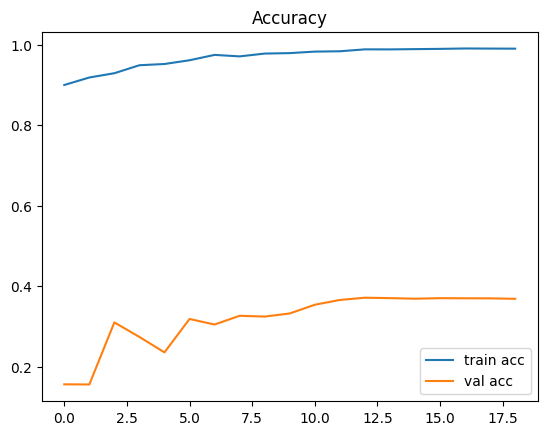

In [18]:
NO_DIRECTION = True

def make_ds_packet(df_sub: pd.DataFrame, no_direction: bool = False, batch_size: int = 64, shuffle: bool = True):
    def gen():
        for _, row in df_sub.iterrows():
            y = int(row["y"])
            dev = row["device_id"]
            p = row["pcap_path"]
            for Xpkt, Xsum, y_ in iter_time_windows(p, device_id=dev, label=y, no_direction=no_direction):
                yield Xpkt, y_
    out_sig = (
        tf.TensorSpec(shape=(T_MAX, Fp), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    ds = tf.data.Dataset.from_generator(gen, output_signature=out_sig)
    if shuffle:
        ds = ds.shuffle(2048, seed=RANDOM_STATE, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds_packet(train_df, no_direction=NO_DIRECTION, batch_size=64, shuffle=True)
test_ds  = make_ds_packet(test_df,  no_direction=NO_DIRECTION, batch_size=64, shuffle=False)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
]

history = model.fit(train_ds, validation_data=test_ds, epochs=30, callbacks=callbacks)

plt.figure()
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend(); plt.title("Accuracy"); plt.show()


## 9) Evaluate

Window-level classification report:
                       precision    recall  f1-score   support

 continuous_streaming     0.3870    0.9975    0.5577       400
interactive_actuators     0.2872    0.1350    0.1837       200
   low_rate_telemetry     0.4506    0.1825    0.2598       400
  smart_media_clients     0.2035    0.0575    0.0897       400

             accuracy                         0.3729      1400
            macro avg     0.3321    0.3431    0.2727      1400
         weighted avg     0.3385    0.3729    0.2854      1400



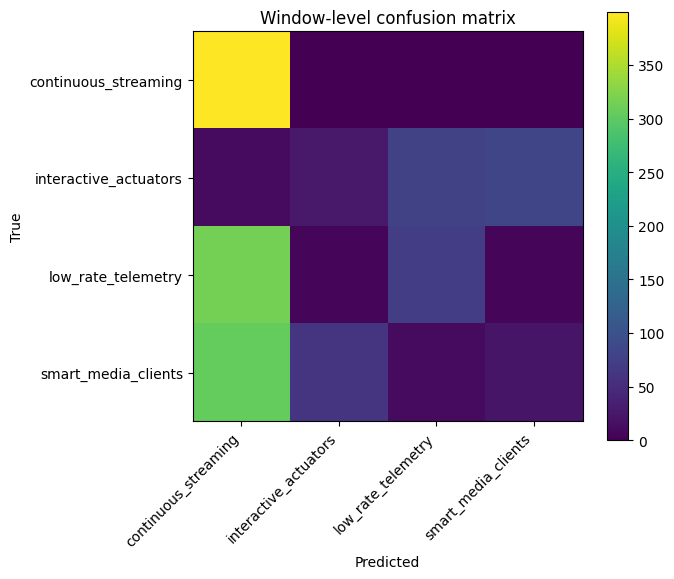

Per-device predictions:
- NestDropCam_308cfb2fe4b2            true=continuous_streaming   pred=continuous_streaming   windows=200
- PixStarPhotoFrame_e076d033bb85      true=smart_media_clients    pred=continuous_streaming   windows=200
- PhilipsHue_0017882b9a25             true=interactive_actuators  pred=low_rate_telemetry     windows=200
- BlipCareBPMeter_746a89002e25        true=low_rate_telemetry     pred=continuous_streaming   windows=200
- HelloBarbie_28c2ddffa52d            true=smart_media_clients    pred=continuous_streaming   windows=200
- WithingsSmartScale_0024e41b6f96     true=low_rate_telemetry     pred=continuous_streaming   windows=200
- SamsungCamera_00166cab6b88          true=continuous_streaming   pred=continuous_streaming   windows=200
Device-level classification report (mean-prob aggregation):
                       precision    recall  f1-score   support

 continuous_streaming     0.3333    1.0000    0.5000         2
interactive_actuators     0.0000    0.0000    0

/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zer

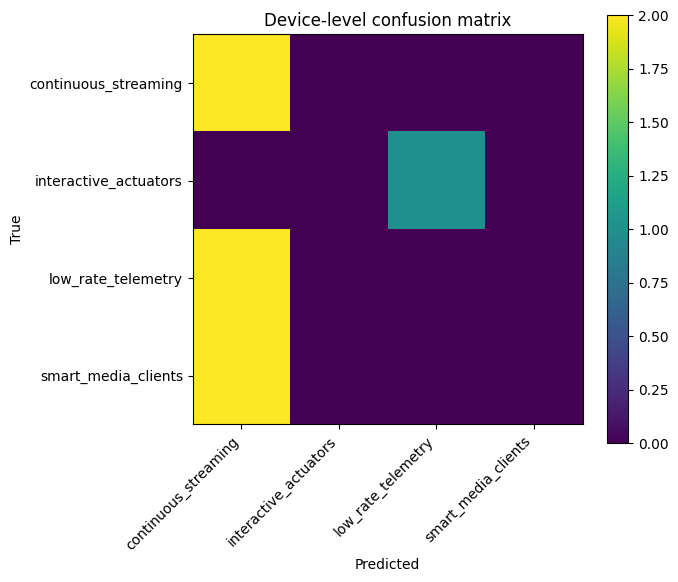

In [19]:
def collect_preds_packet_only(df_sub: pd.DataFrame, model: tf.keras.Model, no_direction: bool = False, max_windows_per_device: int = 200):
    all_true = []
    all_pred = []
    per_device = []

    for _, row in df_sub.iterrows():
        dev = row["device_id"]
        y_true = int(row["y"])
        pcap_path = row["pcap_path"]

        probs = []
        wcount = 0
        for Xpkt, Xsum, y_ in iter_time_windows(pcap_path, device_id=dev, label=y_true, no_direction=no_direction, max_windows=max_windows_per_device):
            p = model.predict(Xpkt[None, ...], verbose=0)[0]
            probs.append(p)
            y_hat = int(np.argmax(p))
            all_true.append(y_true)
            all_pred.append(y_hat)
            wcount += 1

        if probs:
            probs_mean = np.mean(np.stack(probs, axis=0), axis=0)
            y_dev = int(np.argmax(probs_mean))
        else:
            probs_mean = np.zeros((n_classes,), dtype=np.float32)
            y_dev = -1

        per_device.append((dev, y_true, probs_mean, y_dev, wcount))

    return np.array(all_true), np.array(all_pred), per_device

def show_reports(win_true, win_pred, dev_preds):
    print("Window-level classification report:")
    print(classification_report(win_true, win_pred, target_names=types, digits=4))

    cm = confusion_matrix(win_true, win_pred, labels=list(range(n_classes)))
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Window-level confusion matrix")
    plt.colorbar()
    plt.xticks(range(n_classes), types, rotation=45, ha="right")
    plt.yticks(range(n_classes), types)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    dev_true = []
    dev_pred = []
    print("Per-device predictions:")
    for dev, y_true, probs_mean, y_dev, wcount in dev_preds:
        if y_dev >= 0:
            dev_true.append(y_true)
            dev_pred.append(y_dev)
        print(f"- {dev:35s} true={idx_to_type[y_true]:22s} pred={idx_to_type.get(y_dev,'(none)'):22s} windows={wcount}")

    dev_true = np.array(dev_true)
    dev_pred = np.array(dev_pred)

    print("Device-level classification report (mean-prob aggregation):")
    print(classification_report(dev_true, dev_pred, target_names=types, digits=4))

    cm2 = confusion_matrix(dev_true, dev_pred, labels=list(range(n_classes)))
    plt.figure(figsize=(7, 6))
    plt.imshow(cm2, interpolation="nearest")
    plt.title("Device-level confusion matrix")
    plt.colorbar()
    plt.xticks(range(n_classes), types, rotation=45, ha="right")
    plt.yticks(range(n_classes), types)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

win_true, win_pred, dev_preds = collect_preds_packet_only(test_df, model, no_direction=NO_DIRECTION, max_windows_per_device=200)
show_reports(win_true, win_pred, dev_preds)